Please use this notebook to perform any initial analyses and model testing!

In [76]:
import pandas as pd
import numpy as np
import os 
import scipy
import kagglehub
from eda_toolkit.first_stage_report_building.ops.generate_report import build_report_regression

In [77]:
def collect_from_kaggle(kaggle_path: str) -> pd.DataFrame:
    path = kagglehub.dataset_download(kaggle_path)
    file_dir = os.listdir(path)
    df_path = f"{path}/{file_dir[0]}"
    df = pd.read_csv(df_path)

    return df

df_bronze = collect_from_kaggle("berkerisen/wind-turbine-scada-dataset")#
df_bronze.to_csv("../data/bronze/bronze.csv")
df_bronze.head()

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286


In [78]:
df_bronze.columns = ['timestamp', 'lv_active_power', 'wind_speed', 'theoretical_power_curve', 'wind_direction']
df_bronze.head()

,timestamp,lv_active_power,wind_speed,theoretical_power_curve,wind_direction
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286


In [79]:
print(df_bronze.columns)

Index(['timestamp', 'lv_active_power', 'wind_speed', 'theoretical_power_curve',
       'wind_direction'],
      dtype='str')


In [80]:
df_bronze['timestamp'] = pd.to_datetime(df_bronze['timestamp'], format='%d %m %Y %H:%M')
print(df_bronze[df_bronze['timestamp'] == pd.NaT])
df_bronze.head()

Empty DataFrame
Columns: [timestamp, lv_active_power, wind_speed, theoretical_power_curve, wind_direction]
Index: []


,timestamp,lv_active_power,wind_speed,theoretical_power_curve,wind_direction
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789
3,2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286


In [81]:
build_report_regression(df_bronze, 'lv_active_power', ['timestamp'])

Saved successfully


In [82]:
print(df_bronze.loc[df_bronze['lv_active_power'] < 0]['lv_active_power'].describe())

count    57.000000
mean     -0.325730
std       0.401506
min      -2.471405
25%      -0.456533
50%      -0.166333
75%      -0.095733
max      -0.000467
Name: lv_active_power, dtype: float64


In [83]:
df_bronze['lv_active_power'] = df_bronze['lv_active_power'].clip(lower = 0)

In [84]:
df_bronze['hour'] = pd.to_datetime(df_bronze['timestamp']).dt.hour
df_bronze['monr'] = pd.to_datetime(df_bronze['timestamp']).dt.hour

In [85]:
print(df_bronze['timestamp'].min())
print(df_bronze['timestamp'].max())

2018-01-01 00:00:00
2018-12-31 23:50:00


In [86]:
df_bronze.to_csv("../data/silver/silver.csv")

In [87]:
df_bronze.head()

,timestamp,lv_active_power,wind_speed,theoretical_power_curve,wind_direction,hour,monr
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904,0,0
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113,0,0
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789,0,0
3,2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087,0,0
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286,0,0


In [88]:
df_bronze['sine_hour'] = np.sin(2 * np.pi * df_bronze['hour']/24)
df_bronze['cosine_hour'] = np.cos(2 * np.pi * df_bronze['hour']/24)

df_bronze = df_bronze.sort_values(by = ['timestamp'])

In [89]:
df_bronze['wind_direction_rad'] = np.deg2rad(df_bronze['wind_direction'])
df_bronze['wind_magnitude_i'] = df_bronze['wind_speed'] * (np.cos(df_bronze['wind_direction_rad']))
df_bronze['wind_magnitude_j'] = df_bronze['wind_speed'] * (np.sin(df_bronze['wind_direction_rad']))

df_bronze.to_csv("../data/gold/gold.csv")

In [90]:
df_bronze['wind_magnitude_i_3h_rolling'] = df_bronze['wind_magnitude_i'].rolling(window = 3).mean()
df_bronze['wind_magnitude_j_3h_rolling'] = df_bronze['wind_magnitude_j'].rolling(window = 3).mean()
df_bronze['wind_speed_3h_rolling'] = df_bronze['wind_speed'].rolling(window = 3).mean()
df_bronze.dropna(inplace=True)

In [91]:
from datetime import datetime

train_month_threshold = datetime(2018, 3, 1, 0, 0, 0, 0)
val_month_threshold = datetime(2018, 4, 1, 0, 0, 0, 0)
test_month_threshold = datetime(2018, 8, 1, 0, 0, 0, 0)

feature_cols = ['wind_speed', 'wind_direction', 'sine_hour', 'cosine_hour', 'wind_magnitude_i', 'wind_magnitude_j', 'wind_magnitude_i_3h_rolling', 'wind_magnitude_j_3h_rolling', 'wind_speed_3h_rolling']
target_col = ['lv_active_power']

df_train = df_bronze.loc[df_bronze['timestamp'] < train_month_threshold]
df_val = df_bronze.loc[(df_bronze['timestamp'] >= train_month_threshold) & (df_bronze['timestamp'] <= val_month_threshold)]

In [92]:
X_train = df_train[feature_cols]
y_train = df_train[target_col]

X_val = df_val[feature_cols]
y_val = df_val[target_col]
t_val = df_val['timestamp']

print(len(X_train))
print(len(X_val))

7847
4464


In [93]:
from sklearn.ensemble import RandomForestRegressor

rf_params = {
    "n_estimators": 300,        # enough trees to stabilize predictions without excessive runtime
    "max_depth": 15,            # caps tree complexity; prevents overfitting on ~50k rows with few features
    "min_samples_split": 10,    # requires a reasonable sample size before splitting further
    "min_samples_leaf": 5,      # avoids leaves fit to tiny, noisy subsets
    "max_features": "sqrt",     # standard default for RF; decorrelates trees
    "n_jobs": -1,                # use all available cores
    "random_state": 42,          # reproducibility
}

rf = RandomForestRegressor(**rf_params)

rf.fit(X_train, y_train)

test_y_hat = rf.predict(X_val)

predictions_set = X_val.copy()

predictions_set['y'] = y_val
predictions_set['y_hat'] = test_y_hat

predictions_set

c:\Users\Home PC\Desktop\Portfolio Repos\wind_turbine_drift_detection\.venv\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,wind_speed,wind_direction,sine_hour,cosine_hour,wind_magnitude_i,wind_magnitude_j,wind_magnitude_i_3h_rolling,wind_magnitude_j_3h_rolling,wind_speed_3h_rolling,y,y_hat
7849,4.684498,51.169159,0.000000,1.000000,2.937289,3.649226,3.734707,2.967519,4.832214,0.000000,220.381211
7850,4.377705,37.424400,0.000000,1.000000,3.476580,2.660393,3.358184,2.993462,4.531201,0.000000,125.040424
7851,3.969311,26.126591,0.000000,1.000000,3.563740,1.747909,3.325870,2.685843,4.343838,0.000000,88.295935
7852,4.819459,37.092079,0.000000,1.000000,3.844325,2.906605,3.628215,2.438302,4.388825,0.000000,180.026666
7853,5.434208,32.177010,0.000000,1.000000,4.599551,2.893915,4.002539,2.516143,4.740993,0.000000,274.394390
...,...,...,...,...,...,...,...,...,...,...,...
12308,17.385700,190.693207,-0.258819,0.965926,-17.083794,-3.225919,-16.653133,-3.374322,16.992630,3603.822998,3521.851846
12309,17.741930,190.921799,-0.258819,0.965926,-17.420565,-3.361546,-17.157864,-3.424394,17.497506,3603.862061,3476.821565
12310,17.912861,192.203598,-0.258819,0.965926,-17.508077,-3.786531,-17.337479,-3.457999,17.680164,3603.931885,3483.665747
12311,18.086639,194.602203,-0.258819,0.965926,-17.502431,-4.559761,-17.477025,-3.902613,17.913810,3603.597900,3551.367744


In [94]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

first_val_mae = mean_absolute_error(y_val, test_y_hat)
print(first_val_mae)

218.7047347579002


In [95]:
first_val_rmse = root_mean_squared_error(y_val, test_y_hat)

print(first_val_rmse)

504.50681245682705


In [96]:
first_val_r2 = r2_score(y_val, test_y_hat)

print(first_val_r2)

0.8808400106059424


In [97]:
predictions_set['residual'] = predictions_set['y'] - predictions_set['y_hat']

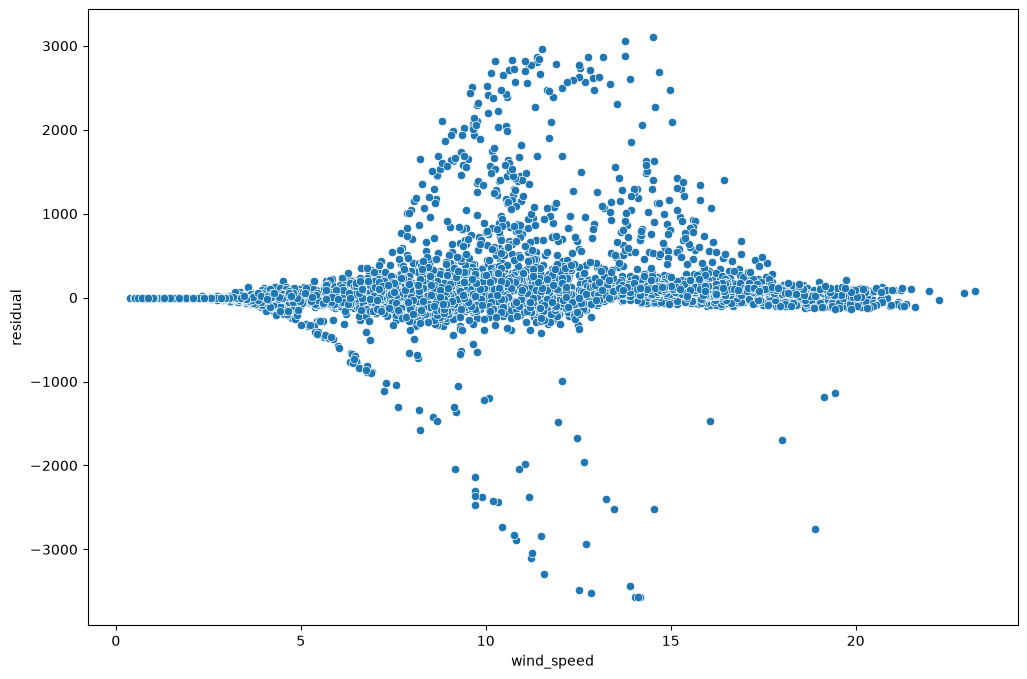

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize = (12, 8))
_ = sns.scatterplot(data = predictions_set, x = 'wind_speed', y = 'residual')

In [99]:
predictions_set['timestamp'] = t_val

negative_resid = predictions_set.loc[predictions_set['residual'] <= -1000]

print(negative_resid['timestamp'].min())
print(negative_resid['timestamp'].max())

2018-03-01 15:50:00
2018-03-27 21:10:00


In [100]:
for timestamp in negative_resid['timestamp']:
    print(timestamp)

2018-03-01 15:50:00
2018-03-01 16:00:00
2018-03-01 16:10:00
2018-03-01 16:20:00
2018-03-01 16:30:00
2018-03-02 14:20:00
2018-03-02 14:30:00
2018-03-02 14:40:00
2018-03-02 14:50:00
2018-03-02 15:00:00
2018-03-02 15:10:00
2018-03-07 08:00:00
2018-03-07 08:10:00
2018-03-07 08:20:00
2018-03-07 08:30:00
2018-03-13 09:50:00
2018-03-13 15:40:00
2018-03-17 06:40:00
2018-03-17 12:00:00
2018-03-17 12:10:00
2018-03-17 12:20:00
2018-03-17 12:30:00
2018-03-17 12:40:00
2018-03-17 12:50:00
2018-03-17 13:00:00
2018-03-17 13:10:00
2018-03-18 13:30:00
2018-03-18 13:40:00
2018-03-18 13:50:00
2018-03-19 09:20:00
2018-03-20 21:10:00
2018-03-20 21:20:00
2018-03-20 21:30:00
2018-03-20 21:40:00
2018-03-23 03:00:00
2018-03-23 03:10:00
2018-03-23 03:20:00
2018-03-26 10:40:00
2018-03-26 10:50:00
2018-03-26 11:30:00
2018-03-26 16:20:00
2018-03-26 16:30:00
2018-03-26 16:40:00
2018-03-26 16:50:00
2018-03-27 00:50:00
2018-03-27 01:00:00
2018-03-27 20:50:00
2018-03-27 21:00:00
2018-03-27 21:10:00


In [101]:
from datetime import timedelta

maes = []
rmses = []
r2s = []
percs = []
for weeks in range(1,10):
    train_month_range = train_month_threshold + timedelta(days = weeks*7)
    val_month_range = val_month_threshold + timedelta(days = weeks*7)

    df_train = df_bronze.loc[df_bronze['timestamp'] < train_month_range]
    df_val = df_bronze.loc[(df_bronze['timestamp'] >= train_month_range) & (df_bronze['timestamp'] <= val_month_range)]

    X_train = df_train[feature_cols]
    y_train = df_train[target_col]

    X_val = df_val[feature_cols]
    y_val = df_val[target_col]

    rf = RandomForestRegressor(**rf_params)

    rf.fit(X_train, y_train)

    test_y_hat = rf.predict(X_val)

    predictions_set = X_val.copy()

    predictions_set['y'] = y_val
    predictions_set['y_hat'] = test_y_hat

    first_val_mae = mean_absolute_error(y_val, test_y_hat)
    first_val_rmse = root_mean_squared_error(y_val, test_y_hat)
    first_val_r2 = r2_score(y_val, test_y_hat)

    maes.append(first_val_mae)
    rmses.append(first_val_rmse)
    r2s.append(first_val_r2)

    df_190 = predictions_set.loc[predictions_set['wind_direction'].between(190, 240)]
    percs.append(len(df_190)/len(predictions_set))


print(maes)
print(rmses)
print(r2s)
print(percs)
    

c:\Users\Home PC\Desktop\Portfolio Repos\wind_turbine_drift_detection\.venv\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Home PC\Desktop\Portfolio Repos\wind_turbine_drift_detection\.venv\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Home PC\Desktop\Portfolio Repos\wind_turbine_drift_detection\.venv\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Home PC\Desktop\Portfolio Repos\wi

[216.42410647274147, 199.57524400938206, 298.0225239871478, 236.69665851631228, 176.4479428978732, 204.97076312325711, 174.8290776165177, 153.22030038045568, 223.94624635466354]
[509.4566692284077, 501.2680350207222, 667.0012104968679, 593.7077851460767, 447.2922941230477, 522.5111442792162, 464.0634697110734, 362.3590091105068, 458.4406013780731]
[0.8760522255903821, 0.877689808584421, 0.7461544213501388, 0.7715326669175868, 0.8371754724660394, 0.7799812738051835, 0.7974259091263335, 0.8688104100036248, 0.7801271056172906]
[0.47232803047277616, 0.351926523297491, 0.20382022471910113, 0.10359550561797753, 0.06735751295336788, 0.07726965532777652, 0.14237592634179205, 0.14013024927015494, 0.12067415730337079]
